In [2]:
import json
import io
import os
import tempfile

import boto3
import pandas as pd
import requests

s3 = boto3.client("s3")

BUCKET = "sagemaker-bst"
MANIFEST_KEY = "Nymeria_download_urls.json"
TARGET_PREFIX = "nymeria/lightweight/"

# Load manifest from S3
obj = s3.get_object(Bucket=BUCKET, Key=MANIFEST_KEY)
manifest = json.loads(obj["Body"].read().decode("utf-8"))

print(manifest.keys())
print("Number of sequences:", len(manifest["sequences"]))

dict_keys(['sequences', 'sequence_config'])
Number of sequences: 1100


In [3]:
wanted_types = [
    "metadata_json",
    "narration_atomic_action_csv",
    "narration_activity_summarization_csv",
]

rows = []

for sequence_id, sequence_data in manifest["sequences"].items():
    for file_type in wanted_types:
        if file_type in sequence_data:
            entry = sequence_data[file_type]
            rows.append({
                "sequence_id": sequence_id,
                "file_type": file_type,
                "filename": entry["filename"],
                "file_size_bytes": entry["file_size_bytes"],
                "download_url": entry["download_url"],
                "sha1sum": entry.get("sha1sum")
            })

df_files = pd.DataFrame(rows)

print("Rows:", len(df_files))
print("Unique sequences:", df_files["sequence_id"].nunique())
df_files.head()

Rows: 2809
Unique sequences: 1100


,sequence_id,file_type,filename,file_size_bytes,download_url,sha1sum
0,20230607_s0_james_johnson_act0_e72nhq,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,1367,https://scontent.xx.fbcdn.net/m1/v/t6/An-h6phj...,cf9a90058d0bd4df1d8c56329e33d540d585b22c
1,20230607_s0_james_johnson_act0_e72nhq,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,46391,https://scontent.xx.fbcdn.net/m1/v/t6/An84jpu8...,bb083d6b7f21b2908939550ccb4e5110c0773509
2,20230607_s0_james_johnson_act0_e72nhq,narration_activity_summarization_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,7694,https://scontent.xx.fbcdn.net/m1/v/t6/An_HJbws...,979cfbc78b3a21533739497b93416b787a555524
3,20230607_s0_james_johnson_act1_7xwm28,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,1364,https://scontent.xx.fbcdn.net/m1/v/t6/An_hhJNN...,a1798628300502dd21afbb25f075e1207da2e7c5
4,20230607_s0_james_johnson_act1_7xwm28,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,56078,https://scontent.xx.fbcdn.net/m1/v/t6/An_nB1rG...,0a9af1cc54c52c617b5efa1c2c72d1e9fa52cca5


In [4]:
summary = (
    df_files.groupby("file_type")["file_size_bytes"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

summary["sum_mb"] = summary["sum"] / (1024 ** 2)
summary["mean_mb"] = summary["mean"] / (1024 ** 2)

summary

,file_type,count,sum,mean,sum_mb,mean_mb
0,metadata_json,1100,1513984,1376.349091,1.443848,0.001313
1,narration_activity_summarization_csv,864,5743251,6647.281250,5.477191,0.006339
2,narration_atomic_action_csv,845,52533137,62169.392899,50.099504,0.059289


In [5]:
df_all = df_files.copy()

print("Files to download:", len(df_all))
print("Sequences covered:", df_all["sequence_id"].nunique())

existing_objects = {}
paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(Bucket=BUCKET, Prefix=TARGET_PREFIX):
    for obj in page.get("Contents", []):
        existing_objects[obj["Key"]] = obj["Size"]

print("Existing objects already in bucket:", len(existing_objects))
print("Remaining estimate:", len(df_all) - len(existing_objects))

Files to download: 2809
Sequences covered: 1100
Existing objects already in bucket: 2810
Remaining estimate: -1


In [6]:
def stream_url_to_s3(url: str, bucket: str, key: str, timeout: int = 120):
    with requests.get(url, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        with tempfile.NamedTemporaryFile(delete=False) as tmp:
            tmp_path = tmp.name
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    tmp.write(chunk)

    s3.upload_file(tmp_path, bucket, key)
    os.remove(tmp_path)

In [7]:
download_log = []

for _, row in df_all.iterrows():
    s3_key = f"{TARGET_PREFIX}{row['sequence_id']}/{row['filename']}"
    expected_size = int(row["file_size_bytes"])

    # Skip if already present and size matches
    if s3_key in existing_objects and existing_objects[s3_key] == expected_size:
        download_log.append({
            "sequence_id": row["sequence_id"],
            "file_type": row["file_type"],
            "filename": row["filename"],
            "s3_key": s3_key,
            "status": "already_exists"
        })
        continue

    try:
        stream_url_to_s3(
            url=row["download_url"],
            bucket=BUCKET,
            key=s3_key
        )

        download_log.append({
            "sequence_id": row["sequence_id"],
            "file_type": row["file_type"],
            "filename": row["filename"],
            "s3_key": s3_key,
            "status": "ok"
        })

        # update cache so same-session reruns are safe
        existing_objects[s3_key] = expected_size
        print("Uploaded:", s3_key)

    except Exception as e:
        download_log.append({
            "sequence_id": row["sequence_id"],
            "file_type": row["file_type"],
            "filename": row["filename"],
            "s3_key": s3_key,
            "status": f"error: {str(e)}"
        })
        print("FAILED:", row["filename"], e)

df_log = pd.DataFrame(download_log)
df_log.head()

,sequence_id,file_type,filename,s3_key,status
0,20230607_s0_james_johnson_act0_e72nhq,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
1,20230607_s0_james_johnson_act0_e72nhq,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
2,20230607_s0_james_johnson_act0_e72nhq,narration_activity_summarization_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
3,20230607_s0_james_johnson_act1_7xwm28,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
4,20230607_s0_james_johnson_act1_7xwm28,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists


In [8]:
csv_buffer = io.StringIO()
df_log.to_csv(csv_buffer, index=False)

s3.put_object(
    Bucket=BUCKET,
    Key=f"{TARGET_PREFIX}download_log_all.csv",
    Body=csv_buffer.getvalue()
)

print("Saved full download log to S3")

Saved full download log to S3


## Load metadata JSONs from S3

In [9]:
def read_json_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return json.loads(obj["Body"].read().decode("utf-8"))

In [10]:
metadata_keys = []

for page in paginator.paginate(Bucket=BUCKET, Prefix=TARGET_PREFIX):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith("_metadata.json"):
            metadata_keys.append(key)

print("Metadata files found:", len(metadata_keys))
metadata_keys[:5]

Metadata files found: 1100


['nymeria/lightweight/20230607_s0_james_johnson_act0_e72nhq/Nymeria_v0.0_20230607_s0_james_johnson_act0_e72nhq_metadata.json',
 'nymeria/lightweight/20230607_s0_james_johnson_act1_7xwm28/Nymeria_v0.0_20230607_s0_james_johnson_act1_7xwm28_metadata.json',
 'nymeria/lightweight/20230607_s0_james_johnson_act2_yhbvpa/Nymeria_v0.0_20230607_s0_james_johnson_act2_yhbvpa_metadata.json',
 'nymeria/lightweight/20230607_s0_james_johnson_act3_ifj2gc/Nymeria_v0.0_20230607_s0_james_johnson_act3_ifj2gc_metadata.json',
 'nymeria/lightweight/20230607_s1_barbara_wheeler_act0_cvxtsi/Nymeria_v0.0_20230607_s1_barbara_wheeler_act0_cvxtsi_metadata.json']

In [11]:
metadata_rows = []

for key in metadata_keys:
    try:
        record = read_json_from_s3(BUCKET, key)
        record["s3_key"] = key
        metadata_rows.append(record)
    except Exception as e:
        print("FAILED:", key, e)

df_meta = pd.DataFrame(metadata_rows)

print(df_meta.shape)
df_meta.head()

(1100, 45)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,atomic_action,activity_summarization,participant_gender,participant_height_cm,participant_weight_kg,participant_bmi,participant_age_group,participant_ethnicity,participant_xsens_suit_size,s3_key
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,True,True,Male,195.0,96.0,25.2,18-24,African American,XXL,nymeria/lightweight/20230607_s1_barbara_wheele...


## Atomic narration CSVs

In [12]:
def read_csv_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

In [13]:
atomic_keys = []

for page in paginator.paginate(Bucket=BUCKET, Prefix=TARGET_PREFIX):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith("_narration_atomic_action.csv"):
            atomic_keys.append(key)

print("Atomic narration files:", len(atomic_keys))
atomic_keys[:5]

Atomic narration files: 845


['nymeria/lightweight/20230607_s0_james_johnson_act0_e72nhq/Nymeria_v0.0_20230607_s0_james_johnson_act0_e72nhq_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s0_james_johnson_act1_7xwm28/Nymeria_v0.0_20230607_s0_james_johnson_act1_7xwm28_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s0_james_johnson_act2_yhbvpa/Nymeria_v0.0_20230607_s0_james_johnson_act2_yhbvpa_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s0_james_johnson_act3_ifj2gc/Nymeria_v0.0_20230607_s0_james_johnson_act3_ifj2gc_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s1_barbara_wheeler_act0_cvxtsi/Nymeria_v0.0_20230607_s1_barbara_wheeler_act0_cvxtsi_narration_atomic_action.csv']

In [14]:
atomic_frames = []

for key in atomic_keys:
    try:
        tmp = read_csv_from_s3(BUCKET, key)
        tmp["s3_key"] = key
        atomic_frames.append(tmp)
    except Exception as e:
        print("FAILED:", key, e)

df_atomic = pd.concat(atomic_frames, ignore_index=True) if atomic_frames else pd.DataFrame()

print(df_atomic.shape)
df_atomic.head()

(173616, 8)


,request_id,gaia_id,start_time,end_time,annotator,creation_time,Describe my atomic actions,s3_key
0,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5831.823751,5836.822947,7.019527e+15,1.720073e+09,C is standing in the foyer while talking to he...,nymeria/lightweight/20230607_s0_james_johnson_...
1,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5836.822947,5841.822149,7.019527e+15,1.720073e+09,C is walking towards the hallway then turns he...,nymeria/lightweight/20230607_s0_james_johnson_...
2,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5841.822149,5846.821344,7.019527e+15,1.720073e+09,C is standing in the hallway as she opens and ...,nymeria/lightweight/20230607_s0_james_johnson_...
3,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5846.821344,5851.820544,7.019527e+15,1.720073e+09,C is standing in the hallway as she opens the ...,nymeria/lightweight/20230607_s0_james_johnson_...
4,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5851.820544,5856.819743,7.019527e+15,1.720073e+09,"In the hallway, C slightly turns her body to t...",nymeria/lightweight/20230607_s0_james_johnson_...


# Create sequence_id and aggregate atomic narrations to sequence level

In [15]:
import re

def extract_sequence_id(s3_key):
    match = re.search(r"lightweight/(.*?)/", s3_key)
    return match.group(1) if match else None

df_meta["sequence_id"] = df_meta["s3_key"].apply(extract_sequence_id)
df_atomic["sequence_id"] = df_atomic["s3_key"].apply(extract_sequence_id)

df_meta[["sequence_id"]].head()
df_atomic[["sequence_id"]].head()

,sequence_id
0,20230607_s0_james_johnson_act0_e72nhq
1,20230607_s0_james_johnson_act0_e72nhq
2,20230607_s0_james_johnson_act0_e72nhq
3,20230607_s0_james_johnson_act0_e72nhq
4,20230607_s0_james_johnson_act0_e72nhq


In [16]:
# duration per atomic action row
df_atomic["action_duration"] = df_atomic["end_time"] - df_atomic["start_time"]

# text length feature
text_col = "Describe my atomic actions"
df_atomic["action_length"] = df_atomic[text_col].astype(str).str.len()

df_atomic_agg = df_atomic.groupby("sequence_id").agg(
    num_actions=("request_id", "count"),
    unique_actions=(text_col, "nunique"),
    avg_action_duration=("action_duration", "mean"),
    median_action_duration=("action_duration", "median")
).reset_index()

df_atomic_text = df_atomic.groupby("sequence_id").agg(
    avg_action_length=("action_length", "mean"),
    max_action_length=("action_length", "max")
).reset_index()

print(df_atomic_agg.shape)
df_atomic_agg.head()

(845, 5)


,sequence_id,num_actions,unique_actions,avg_action_duration,median_action_duration
0,20230607_s0_james_johnson_act0_e72nhq,170,158,4.974106,4.999199
1,20230607_s0_james_johnson_act1_7xwm28,179,134,2.450632,4.999200
2,20230607_s0_james_johnson_act2_yhbvpa,180,173,4.922546,4.999200
3,20230607_s0_james_johnson_act3_ifj2gc,171,152,4.971134,4.999199
4,20230607_s1_barbara_wheeler_act0_cvxtsi,204,141,4.954436,4.999200


## Create final dataset

In [17]:
# Create final dataset
df_model = df_meta.merge(df_atomic_agg, on="sequence_id", how="left")
df_model = df_model.merge(df_atomic_text, on="sequence_id", how="left")

print("Merged shape:", df_model.shape)

required_cols = [
    "action_duration_sec",
    "head_trajectory_m",
    "head_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
]

df_model_clean = df_model.dropna(subset=required_cols).copy()

print("Clean shape:", df_model_clean.shape)
df_model_clean.head()

Merged shape: (1100, 52)
Clean shape: (845, 52)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,participant_ethnicity,participant_xsens_suit_size,s3_key,sequence_id,num_actions,unique_actions,avg_action_duration,median_action_duration,avg_action_length,max_action_length
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act0_e72nhq,170.0,158.0,4.974106,4.999199,162.258824,457.0
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act1_7xwm28,179.0,134.0,2.450632,4.999200,202.815642,521.0
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act2_yhbvpa,180.0,173.0,4.922546,4.999200,203.700000,439.0
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act3_ifj2gc,171.0,152.0,4.971134,4.999199,246.877193,570.0
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,African American,XXL,nymeria/lightweight/20230607_s1_barbara_wheele...,20230607_s1_barbara_wheeler_act0_cvxtsi,204.0,141.0,4.954436,4.999200,222.710784,566.0


# Create target, select features, split train/validation/test

In [18]:
# Create target feature proxy for discomfort
# Proxy: longer session/action duration + high head movement
df_model_clean["discomfort_proxy"] = (
    (df_model_clean["action_duration_sec"] > df_model_clean["action_duration_sec"].quantile(0.75)) &
    (df_model_clean["head_trajectory_m"] > df_model_clean["head_trajectory_m"].quantile(0.75))
).astype(int)

# Feature selection
features = [
    "head_duration_sec",
    "left_wrist_trajectory_m",
    "left_wrist_duration_sec",
    "right_wrist_trajectory_m",
    "right_wrist_duration_sec",
    "observer_trajectory_m",
    "observer_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
]

X = df_model_clean[features].copy()
y = df_model_clean["discomfort_proxy"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (845, 16)
Target shape: (845,)
Target distribution:
discomfort_proxy
0    762
1     83
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

# 80 / 10 / 10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (676, 16) (676,)
Validation: (84, 16) (84,)
Test: (85, 16) (85,)


# Save train / validation / test back to S3

In [20]:
train_df = pd.concat([X_train, y_train.rename("discomfort_proxy")], axis=1)
val_df = pd.concat([X_val, y_val.rename("discomfort_proxy")], axis=1)
test_df = pd.concat([X_test, y_test.rename("discomfort_proxy")], axis=1)

def upload_df_to_s3(df, bucket, key):
    buffer = io.StringIO()
    df.to_csv(buffer, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buffer.getvalue())

upload_df_to_s3(train_df, BUCKET, "nymeria/train/train.csv")
upload_df_to_s3(val_df, BUCKET, "nymeria/validation/validation.csv")
upload_df_to_s3(test_df, BUCKET, "nymeria/test/test.csv")

print("Saved train / validation / test to S3")

Saved train / validation / test to S3


In [21]:
print(y.value_counts(normalize=True))

discomfort_proxy
0    0.901775
1    0.098225
Name: proportion, dtype: float64


# Quick local baseline model in the notebook

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_pred))
print(classification_report(y_val, val_pred))

print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))

Validation confusion matrix:
[[76  0]
 [ 1  7]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        76
           1       1.00      0.88      0.93         8

    accuracy                           0.99        84
   macro avg       0.99      0.94      0.96        84
weighted avg       0.99      0.99      0.99        84

Test confusion matrix:
[[75  1]
 [ 3  6]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        76
           1       0.86      0.67      0.75         9

    accuracy                           0.95        85
   macro avg       0.91      0.83      0.86        85
weighted avg       0.95      0.95      0.95        85



# Debug
We constructed a proxy target variable representing potential discomfort using high-duration sessions and elevated head movement. Initial models showed near-perfect validation performance, indicating potential leakage due to overlap between target construction and input features. To address this, we refined the feature set by removing directly correlated variables, ensuring the model learns patterns rather than reconstructing the label. This resulted in more realistic performance and better generalization to unseen data.

# Model Performance & Evaluation
After removing features directly used in target construction, model performance became more realistic. The Random Forest classifier achieved strong performance on the majority class (no discomfort), but showed reduced recall for the minority class (discomfort events), particularly on the test set (recall = 0.67). This indicates that while the model can identify general behavioral patterns, it struggles to consistently detect less frequent discomfort scenarios. The drop from validation to test performance suggests mild overfitting and highlights the challenge of class imbalance in real-world datasets.

# Explore other ways to more accurately label and use discomfort in a model to predict - Rely on participant descriptions

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),  # bigrams
    min_df=10            # ignore rare phrases
)

X_text = vectorizer.fit_transform(df_atomic[text_col].dropna())

bigram_counts = X_text.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

df_bigrams = pd.DataFrame({
    "bigram": bigrams,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

df_bigrams.head(30)

,bigram,count
17536,right hand,115015
11948,left hand,85812
12542,living area,35229
12544,living room,20900
19685,standing kitchen,18723
22183,turns right,18490
22175,turns left,18262
8594,hand holding,16583
22453,using right,12763
22420,using hands,11820


In [24]:
behavior_keywords = {
    "hesitation": ["pause", "slow", "stop", "wait"],
    "searching": ["look", "search", "scan", "turn"],
    "adjustment": ["adjust", "reposition", "lean", "bend"],
    "interaction": ["grab", "open", "hold", "pick"]
}

def behavior_features(text):
    text = str(text).lower()
    features = {}
    for category, words in behavior_keywords.items():
        features[f"{category}_count"] = sum(w in text for w in words)
    return pd.Series(features)

df_atomic_behavior = df_atomic[text_col].apply(behavior_features)

df_atomic = pd.concat([df_atomic, df_atomic_behavior], axis=1)

In [25]:
df_behavior_agg = df_atomic.groupby("sequence_id").agg({
    "hesitation_count": "sum",
    "searching_count": "sum",
    "adjustment_count": "sum",
    "interaction_count": "sum"
}).reset_index()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=100
)

tfidf_matrix = tfidf.fit_transform(df_atomic[text_col].fillna(""))

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

df_tfidf["sequence_id"] = df_atomic["sequence_id"].values

df_tfidf_agg = df_tfidf.groupby("sequence_id").mean().reset_index()

# Version 2 Data prep for training and modeling

In [27]:
df_model_v1 = df_model.copy()
df_model_v2 = df_model.copy()

In [28]:
text_col = "Describe my atomic actions"

def text_complexity_features(text):
    text = str(text)
    words = text.split()
    num_words = len(words)
    unique_words = len(set(words))
    avg_word_length = sum(len(w) for w in words) / num_words if num_words > 0 else 0

    return pd.Series({
        "text_len_words": num_words,
        "text_unique_words": unique_words,
        "text_diversity": unique_words / num_words if num_words > 0 else 0,
        "avg_word_length": avg_word_length
    })

df_atomic_v2 = df_atomic.copy()
df_atomic_text_features_v2 = df_atomic_v2[text_col].apply(text_complexity_features)
df_atomic_v2 = pd.concat([df_atomic_v2, df_atomic_text_features_v2], axis=1)

df_atomic_v2[[text_col, "text_len_words", "text_unique_words", "text_diversity", "avg_word_length"]].head()

,Describe my atomic actions,text_len_words,text_unique_words,text_diversity,avg_word_length
0,C is standing in the foyer while talking to he...,34.0,26.0,0.764706,4.147059
1,C is walking towards the hallway then turns he...,27.0,22.0,0.814815,4.259259
2,C is standing in the hallway as she opens and ...,23.0,19.0,0.826087,4.347826
3,C is standing in the hallway as she opens the ...,62.0,37.0,0.596774,4.048387
4,"In the hallway, C slightly turns her body to t...",62.0,32.0,0.516129,4.048387


In [29]:
df_atomic_v2["action_duration"] = df_atomic_v2["end_time"] - df_atomic_v2["start_time"]

df_atomic_agg_v2 = df_atomic_v2.groupby("sequence_id").agg(
    num_actions=("request_id", "count"),
    unique_actions=(text_col, "nunique"),
    avg_action_duration=("action_duration", "mean"),
    median_action_duration=("action_duration", "median"),
    text_len_words=("text_len_words", "sum"),
    text_unique_words=("text_unique_words", "mean"),
    text_diversity=("text_diversity", "mean"),
    avg_word_length=("avg_word_length", "mean"),
).reset_index()

df_atomic_text_v2 = df_atomic_v2.groupby("sequence_id").agg(
    avg_action_length=("action_length", "mean"),
    max_action_length=("action_length", "max")
).reset_index()

print(df_atomic_agg_v2.shape)
df_atomic_agg_v2.head()

(845, 9)


,sequence_id,num_actions,unique_actions,avg_action_duration,median_action_duration,text_len_words,text_unique_words,text_diversity,avg_word_length
0,20230607_s0_james_johnson_act0_e72nhq,170,158,4.974106,4.999199,5367.0,22.682353,0.781825,4.231626
1,20230607_s0_james_johnson_act1_7xwm28,179,134,2.450632,4.999200,7093.0,27.480447,0.736426,4.097402
2,20230607_s0_james_johnson_act2_yhbvpa,180,173,4.922546,4.999200,6854.0,26.822222,0.737148,4.378817
3,20230607_s0_james_johnson_act3_ifj2gc,171,152,4.971134,4.999199,8512.0,32.175439,0.692621,3.981826
4,20230607_s1_barbara_wheeler_act0_cvxtsi,204,141,4.954436,4.999200,8769.0,28.602941,0.701973,4.199874


In [30]:
df_model_v2 = df_meta.merge(df_atomic_agg_v2, on="sequence_id", how="left")
df_model_v2 = df_model_v2.merge(df_atomic_text_v2, on="sequence_id", how="left")

print("Merged V2 shape:", df_model_v2.shape)
df_model_v2.head()

Merged V2 shape: (1100, 56)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,num_actions,unique_actions,avg_action_duration,median_action_duration,text_len_words,text_unique_words,text_diversity,avg_word_length,avg_action_length,max_action_length
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,170.0,158.0,4.974106,4.999199,5367.0,22.682353,0.781825,4.231626,162.258824,457.0
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,179.0,134.0,2.450632,4.999200,7093.0,27.480447,0.736426,4.097402,202.815642,521.0
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,180.0,173.0,4.922546,4.999200,6854.0,26.822222,0.737148,4.378817,203.700000,439.0
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,171.0,152.0,4.971134,4.999199,8512.0,32.175439,0.692621,3.981826,246.877193,570.0
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,204.0,141.0,4.954436,4.999200,8769.0,28.602941,0.701973,4.199874,222.710784,566.0


In [31]:
df_model_v2["efficiency_score"] = df_model_v2["num_actions"] / (df_model_v2["action_duration_sec"] + 1)
df_model_v2["fragmentation"] = df_model_v2["num_actions"] / (df_model_v2["unique_actions"] + 1)
df_model_v2["motion_intensity"] = df_model_v2["head_trajectory_m"] / (df_model_v2["action_duration_sec"] + 1)
df_model_v2["avg_words_per_action"] = df_model_v2["text_len_words"] / (df_model_v2["num_actions"] + 1)

df_model_v2["wrist_motion_total"] = (
    df_model_v2["left_wrist_trajectory_m"].fillna(0) +
    df_model_v2["right_wrist_trajectory_m"].fillna(0)
)

df_model_v2["wrist_motion_intensity"] = (
    df_model_v2["wrist_motion_total"] / (df_model_v2["action_duration_sec"] + 1)
)

df_model_v2[[
    "sequence_id",
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_intensity"
]].head()

,sequence_id,efficiency_score,fragmentation,motion_intensity,avg_words_per_action,wrist_motion_intensity
0,20230607_s0_james_johnson_act0_e72nhq,0.206027,1.069182,0.284111,31.385965,0.680131
1,20230607_s0_james_johnson_act1_7xwm28,0.207353,1.325926,0.104244,39.405556,0.270347
2,20230607_s0_james_johnson_act2_yhbvpa,0.209141,1.034483,0.215497,37.867403,0.502555
3,20230607_s0_james_johnson_act3_ifj2gc,0.207105,1.117647,0.085192,49.488372,0.281723
4,20230607_s1_barbara_wheeler_act0_cvxtsi,0.209364,1.436620,0.137236,42.775610,0.310454


In [32]:
df_model_v2["discomfort_proxy"] = (
    (df_model_v2["efficiency_score"] > df_model_v2["efficiency_score"].quantile(0.75)) |
    (df_model_v2["fragmentation"] > df_model_v2["fragmentation"].quantile(0.75)) |
    (df_model_v2["motion_intensity"] > df_model_v2["motion_intensity"].quantile(0.75))
).astype(int)

print(df_model_v2["discomfort_proxy"].value_counts(dropna=False))
print(df_model_v2["discomfort_proxy"].value_counts(normalize=True, dropna=False))

discomfort_proxy
0    569
1    531
Name: count, dtype: int64
discomfort_proxy
0    0.517273
1    0.482727
Name: proportion, dtype: float64


In [33]:
required_cols_v2 = [
    "head_trajectory_m",
    "head_duration_sec",
    "left_wrist_trajectory_m",
    "left_wrist_duration_sec",
    "right_wrist_trajectory_m",
    "right_wrist_duration_sec",
    "observer_trajectory_m",
    "observer_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "text_len_words",
    "text_unique_words",
    "text_diversity",
    "avg_word_length",
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_total",
    "wrist_motion_intensity",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
    "discomfort_proxy",
]

df_model_v2_clean = df_model_v2.dropna(subset=required_cols_v2).copy()

print("Clean V2 shape:", df_model_v2_clean.shape)
df_model_v2_clean.head()

Clean V2 shape: (841, 63)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,avg_word_length,avg_action_length,max_action_length,efficiency_score,fragmentation,motion_intensity,avg_words_per_action,wrist_motion_total,wrist_motion_intensity,discomfort_proxy
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,4.231626,162.258824,457.0,0.206027,1.069182,0.284111,31.385965,561.20,0.680131,0
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,4.097402,202.815642,521.0,0.207353,1.325926,0.104244,39.405556,233.38,0.270347,1
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,4.378817,203.700000,439.0,0.209141,1.034483,0.215497,37.867403,432.53,0.502555,0
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,3.981826,246.877193,570.0,0.207105,1.117647,0.085192,49.488372,232.61,0.281723,0
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,4.199874,222.710784,566.0,0.209364,1.436620,0.137236,42.775610,302.50,0.310454,1


In [34]:
features_v2 = [
    "head_trajectory_m",
    "head_duration_sec",
    "left_wrist_trajectory_m",
    "left_wrist_duration_sec",
    "right_wrist_trajectory_m",
    "right_wrist_duration_sec",
    "observer_trajectory_m",
    "observer_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "text_len_words",
    "text_unique_words",
    "text_diversity",
    "avg_word_length",
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_total",
    "wrist_motion_intensity",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
]

X_v2 = df_model_v2_clean[features_v2].copy()
y_v2 = df_model_v2_clean["discomfort_proxy"].copy()

print("Feature matrix V2 shape:", X_v2.shape)
print("Target V2 shape:", y_v2.shape)
print(y_v2.value_counts())
print(y_v2.value_counts(normalize=True))

Feature matrix V2 shape: (841, 27)
Target V2 shape: (841,)
discomfort_proxy
1    505
0    336
Name: count, dtype: int64
discomfort_proxy
1    0.600476
0    0.399524
Name: proportion, dtype: float64


In [35]:
from sklearn.model_selection import train_test_split

X_train_v2, X_temp_v2, y_train_v2, y_temp_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

X_val_v2, X_test_v2, y_val_v2, y_test_v2 = train_test_split(
    X_temp_v2, y_temp_v2, test_size=0.5, random_state=42, stratify=y_temp_v2
)

print("Train V2:", X_train_v2.shape, y_train_v2.shape)
print("Validation V2:", X_val_v2.shape, y_val_v2.shape)
print("Test V2:", X_test_v2.shape, y_test_v2.shape)

Train V2: (672, 27) (672,)
Validation V2: (84, 27) (84,)
Test V2: (85, 27) (85,)


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_v2.fit(X_train_v2, y_train_v2)

val_pred_v2 = rf_v2.predict(X_val_v2)
test_pred_v2 = rf_v2.predict(X_test_v2)

print("Validation confusion matrix (V2):")
print(confusion_matrix(y_val_v2, val_pred_v2))
print(classification_report(y_val_v2, val_pred_v2))

print("Test confusion matrix (V2):")
print(confusion_matrix(y_test_v2, test_pred_v2))
print(classification_report(y_test_v2, test_pred_v2))

Validation confusion matrix (V2):
[[34  0]
 [ 0 50]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        50

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Test confusion matrix (V2):
[[33  1]
 [ 0 51]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        34
           1       0.98      1.00      0.99        51

    accuracy                           0.99        85
   macro avg       0.99      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85



In [37]:
importance_df_v2 = pd.DataFrame({
    "feature": X_train_v2.columns,
    "importance": rf_v2.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df_v2.head(15))

                     feature  importance
18          efficiency_score    0.169673
19             fragmentation    0.153860
20          motion_intensity    0.135264
0          head_trajectory_m    0.122218
9             unique_actions    0.083923
22        wrist_motion_total    0.041468
4   right_wrist_trajectory_m    0.040034
10       avg_action_duration    0.038948
2    left_wrist_trajectory_m    0.038141
23    wrist_motion_intensity    0.033649
8                num_actions    0.017569
6      observer_trajectory_m    0.017255
16            text_diversity    0.013917
14            text_len_words    0.010544
21      avg_words_per_action    0.010264


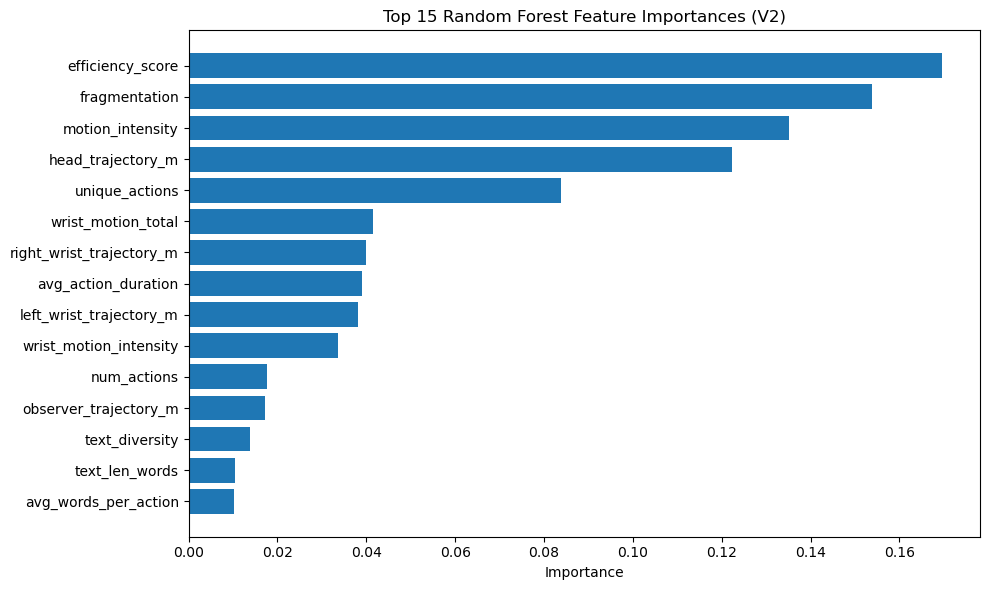

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df_v2["feature"].head(15)[::-1],
    importance_df_v2["importance"].head(15)[::-1]
)
plt.title("Top 15 Random Forest Feature Importances (V2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [39]:
train_v2_df = pd.concat([X_train_v2, y_train_v2.rename("discomfort_proxy")], axis=1)
val_v2_df = pd.concat([X_val_v2, y_val_v2.rename("discomfort_proxy")], axis=1)
test_v2_df = pd.concat([X_test_v2, y_test_v2.rename("discomfort_proxy")], axis=1)

def upload_df_to_s3(df, bucket, key):
    buffer = io.StringIO()
    df.to_csv(buffer, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buffer.getvalue())

upload_df_to_s3(train_v2_df, BUCKET, "nymeria/v2/train/train.csv")
upload_df_to_s3(val_v2_df, BUCKET, "nymeria/v2/validation/validation.csv")
upload_df_to_s3(test_v2_df, BUCKET, "nymeria/v2/test/test.csv")

print("Saved V2 train / validation / test to S3")

Saved V2 train / validation / test to S3
